# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **California Housing Dataset** dari library Scikit-Learn.

Dataset ini berisi informasi sensus perumahan di California pada tahun 1990.

**Tujuan:** Memprediksi nilai median rumah (MedHouseVal) berdasarkan fitur-fitur demografis dan geografis.

**Fitur-fitur:**
- `MedInc` - Median pendapatan dalam blok
- `HouseAge` - Median umur rumah dalam blok
- `AveRooms` - Rata-rata jumlah kamar per rumah tangga
- `AveBedrms` - Rata-rata jumlah kamar tidur per rumah tangga
- `Population` - Populasi blok
- `AveOccup` - Rata-rata jumlah penghuni per rumah tangga
- `Latitude` - Lintang blok
- `Longitude` - Bujur blok

**Target:** `MedHouseVal` - Median nilai rumah (dalam ratusan ribu dolar)

**Jumlah data:** 20.640 sampel

**Sumber:** Scikit-Learn built-in datasets (`sklearn.datasets.fetch_california_housing`)

# **2. Import Library**

Pada tahap ini, kita mengimpor library yang dibutuhkan untuk analisis data dan pemodelan.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
from sklearn.datasets import fetch_california_housing

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Library berhasil diimport!')

Library berhasil diimport!


# **3. Memuat Dataset**

Dataset California Housing dimuat dari scikit-learn dan disimpan ke dalam DataFrame pandas.

In [2]:
# Load dataset dari sklearn
california = fetch_california_housing()

# Buat DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# Simpan sebagai raw CSV
df.to_csv('../california_housing_raw.csv', index=False)
print('Dataset berhasil dimuat dan disimpan sebagai CSV!')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')

Dataset berhasil dimuat dan disimpan sebagai CSV!
Shape: (20640, 9)
Jumlah baris: 20640
Jumlah kolom: 9


In [3]:
# Menampilkan 5 baris pertama
print('=== 5 Baris Pertama ===')
df.head()

=== 5 Baris Pertama ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Menampilkan 5 baris terakhir
print('=== 5 Baris Terakhir ===')
df.tail()

=== 5 Baris Terakhir ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [5]:
# Informasi dataset
print('=== Info Dataset ===')
df.info()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan analisis eksplorasi data untuk memahami karakteristik dataset,
menemukan pola, dan mengidentifikasi potensi masalah dalam data.

## 4.1 Statistik Deskriptif

In [6]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe().round(2)

=== Statistik Deskriptif ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## 4.2 Cek Missing Values & Duplikat

In [7]:
# Cek missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
             Missing Count  Percentage (%)
MedInc                   0             0.0
HouseAge                 0             0.0
AveRooms                 0             0.0
AveBedrms                0             0.0
Population               0             0.0
AveOccup                 0             0.0
Latitude                 0             0.0
Longitude                0             0.0
MedHouseVal              0             0.0

Total missing values: 0


In [8]:
# Cek duplikat
print('=== Data Duplikat ===')
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat: {(duplicates/len(df)*100):.2f}%')

=== Data Duplikat ===
Jumlah baris duplikat: 0
Persentase duplikat: 0.00%


## 4.3 Distribusi Setiap Fitur

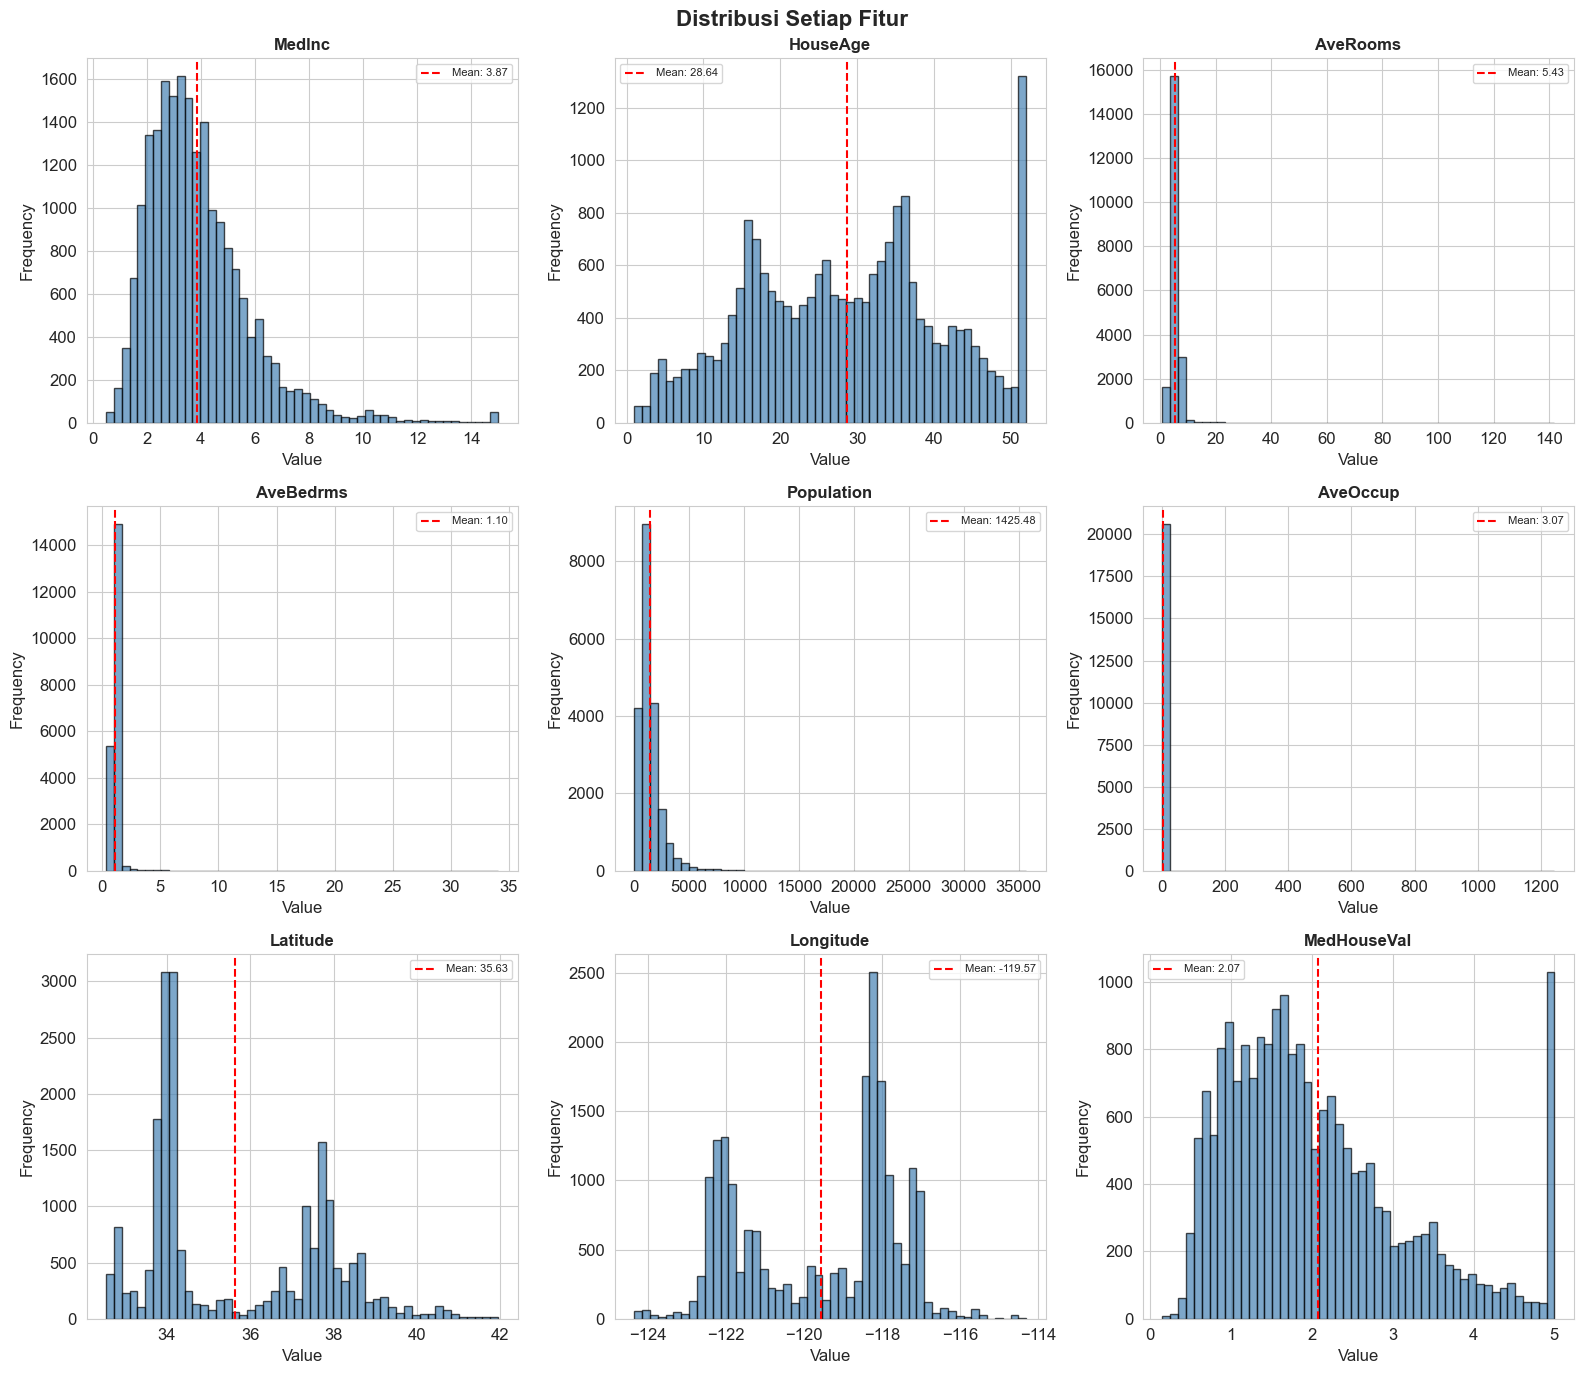

Histogram distribusi disimpan.


In [9]:
# Histogram distribusi semua fitur
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Distribusi Setiap Fitur', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    # Tambahkan mean line
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=100, bbox_inches='tight')
plt.show()
print('Histogram distribusi disimpan.')

## 4.4 Korelasi Antar Fitur

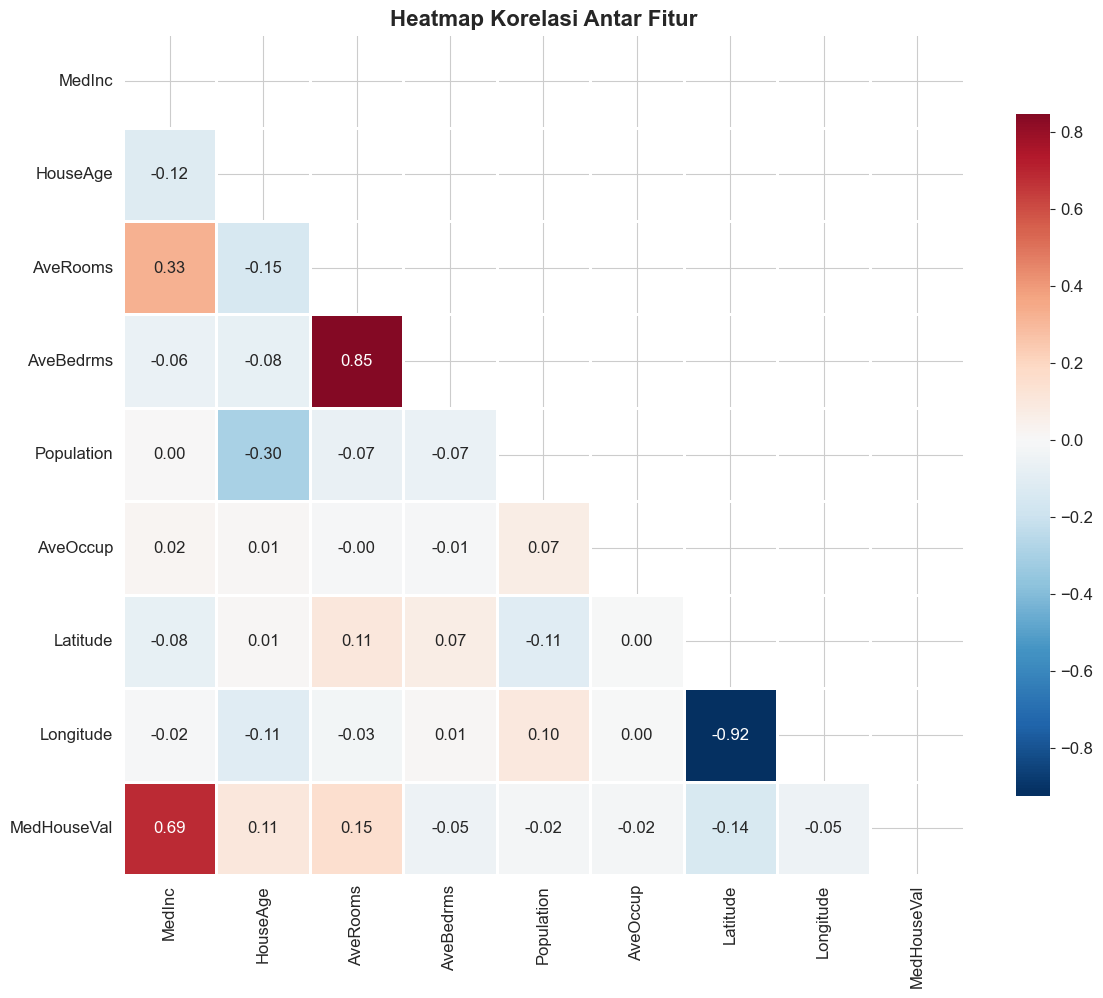


=== Korelasi dengan Target (MedHouseVal) ===
MedInc        0.6881
AveRooms      0.1519
HouseAge      0.1056
AveOccup     -0.0237
Population   -0.0246
Longitude    -0.0460
AveBedrms    -0.0467
Latitude     -0.1442
Name: MedHouseVal, dtype: float64


In [10]:
# Heatmap korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=100, bbox_inches='tight')
plt.show()

# Korelasi dengan target
print('\n=== Korelasi dengan Target (MedHouseVal) ===')
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(target_corr.round(4))

## 4.5 Boxplot untuk Deteksi Outlier

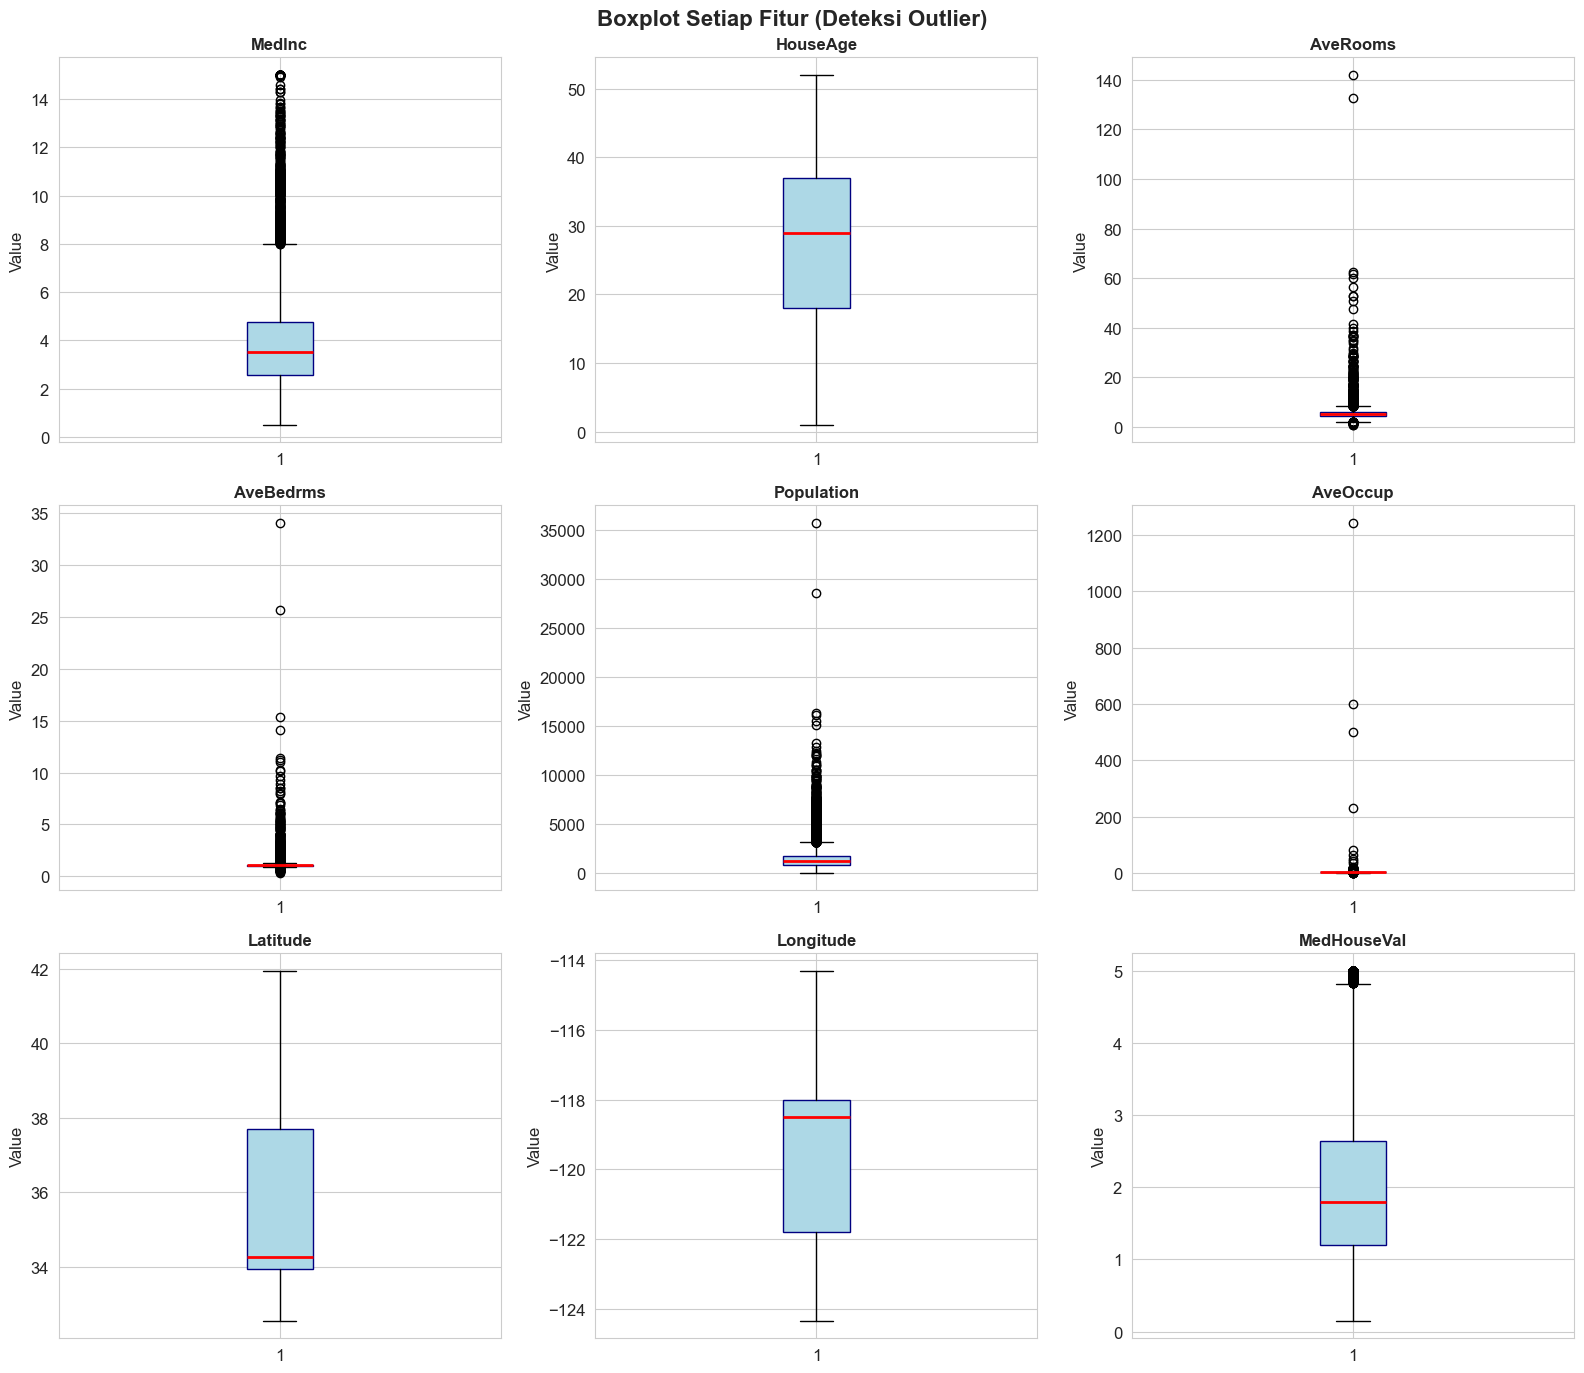

Boxplot disimpan.


In [11]:
# Boxplot untuk semua fitur
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Boxplot Setiap Fitur (Deteksi Outlier)', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Boxplot disimpan.')

## 4.6 Scatter Plot Target vs Fitur Utama

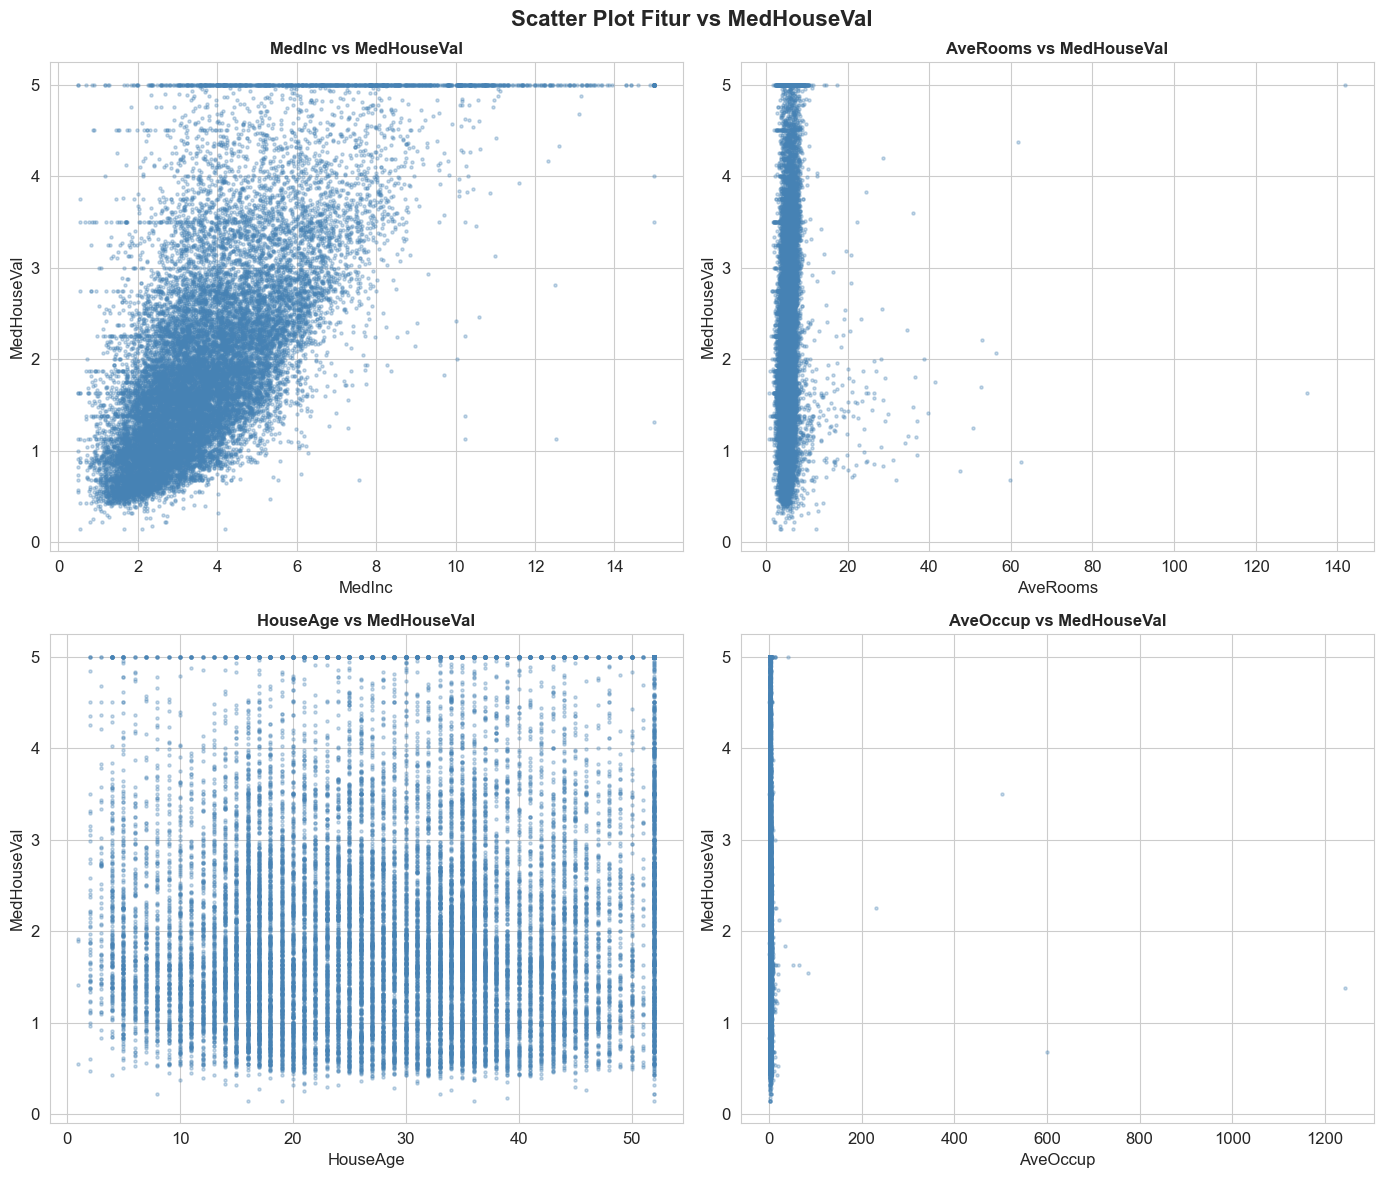

In [12]:
# Scatter plot fitur utama vs target
top_features = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Scatter Plot Fitur vs MedHouseVal', fontsize=16, fontweight='bold')

for idx, feat in enumerate(top_features):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row][col_idx]
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('MedHouseVal', fontsize=12)
    ax.set_title(f'{feat} vs MedHouseVal', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.7 Pairplot Fitur Terpilih

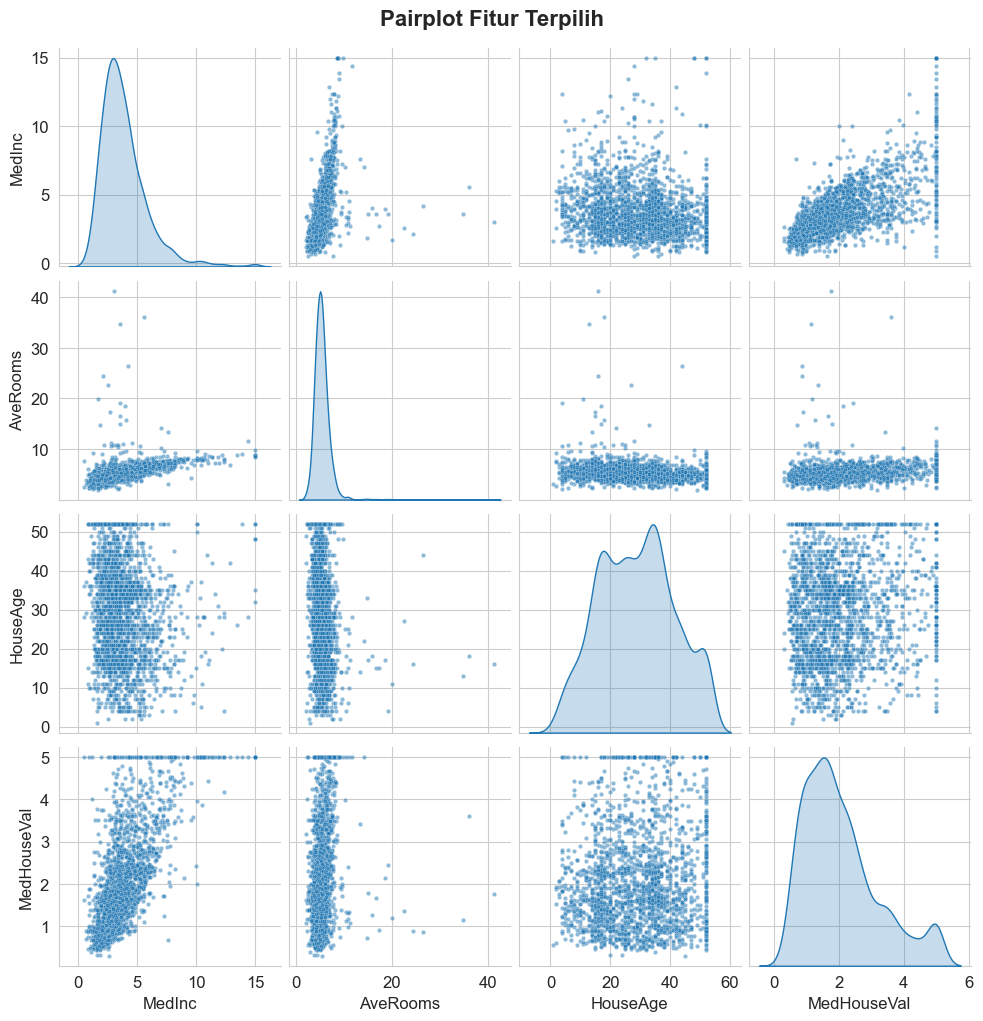

In [13]:
# Pairplot fitur yang paling berkorelasi dengan target
selected_features = ['MedInc', 'AveRooms', 'HouseAge', 'MedHouseVal']
sns.pairplot(df[selected_features].sample(2000, random_state=42), 
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairplot Fitur Terpilih', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.8 Distribusi Geografis

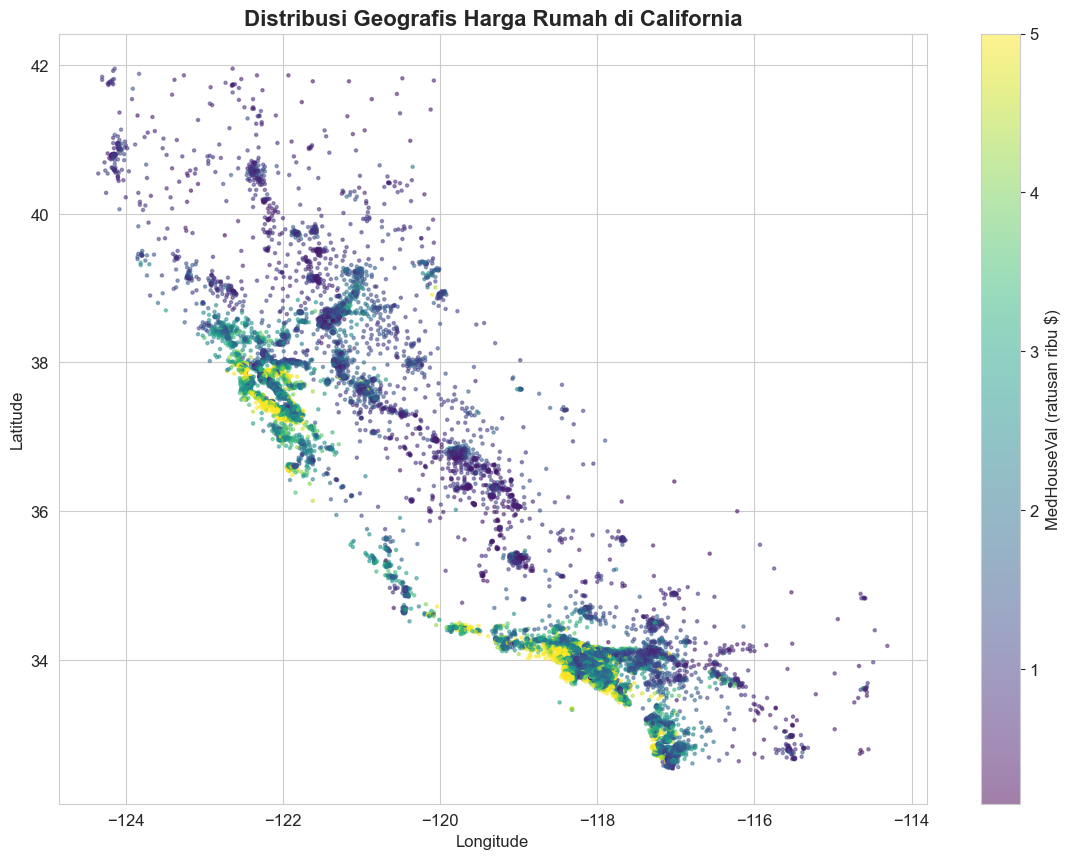

In [14]:
# Visualisasi geografis - Harga rumah berdasarkan lokasi
plt.figure(figsize=(14, 10))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                      c=df['MedHouseVal'], cmap='viridis',
                      alpha=0.5, s=5)
plt.colorbar(scatter, label='MedHouseVal (ratusan ribu $)')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Distribusi Geografis Harga Rumah di California', fontsize=16, fontweight='bold')
plt.savefig('eda_geografis.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.9 Skewness & Kurtosis

In [15]:
# Skewness dan Kurtosis
print('=== Skewness ===')
skew_df = pd.DataFrame({
    'Skewness': df.skew().round(4),
    'Kurtosis': df.kurtosis().round(4)
})
print(skew_df)
print('\nKeterangan:')
print('- Skewness > 1 atau < -1: Distribusi sangat miring')
print('- Kurtosis > 3: Distribusi leptokurtic (ekor tebal)')

=== Skewness ===
             Skewness    Kurtosis
MedInc         1.6467      4.9525
HouseAge       0.0603     -0.8006
AveRooms      20.6979    879.3533
AveBedrms     31.3170   1636.7120
Population     4.9359     73.5531
AveOccup      97.6396  10651.0106
Latitude       0.4660     -1.1178
Longitude     -0.2978     -1.3302
MedHouseVal    0.9778      0.3279

Keterangan:
- Skewness > 1 atau < -1: Distribusi sangat miring
- Kurtosis > 3: Distribusi leptokurtic (ekor tebal)


# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data untuk mempersiapkan data agar siap digunakan dalam model machine learning.

## 5.1 Menghapus Data Duplikat

In [16]:
# Copy dataset untuk preprocessing
df_processed = df.copy()
print(f'Shape sebelum preprocessing: {df_processed.shape}')

# Hapus duplikat
before = len(df_processed)
df_processed = df_processed.drop_duplicates()
after = len(df_processed)
print(f'\nData duplikat dihapus: {before - after} baris')
print(f'Shape setelah hapus duplikat: {df_processed.shape}')

Shape sebelum preprocessing: (20640, 9)

Data duplikat dihapus: 0 baris
Shape setelah hapus duplikat: (20640, 9)


## 5.2 Menangani Missing Values

In [17]:
# Cek missing values
print('=== Missing Values ===')
print(df_processed.isnull().sum())
print(f'\nTotal missing values: {df_processed.isnull().sum().sum()}')

# Jika ada missing values, isi dengan median
if df_processed.isnull().sum().sum() > 0:
    for col in df_processed.columns:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    print('\nMissing values telah diisi dengan median.')
else:
    print('\nTidak ada missing values. Lanjut ke tahap berikutnya.')

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0

Tidak ada missing values. Lanjut ke tahap berikutnya.


## 5.3 Deteksi dan Penanganan Outlier (IQR Method)

In [18]:
# Deteksi outlier menggunakan IQR
def detect_outliers_iqr(dataframe, columns):
    """Deteksi outlier menggunakan metode IQR"""
    outlier_info = {}
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_info[col] = {
            'count': len(outliers),
            'percentage': round(len(outliers)/len(dataframe)*100, 2),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2)
        }
    return outlier_info

# Kolom numerik (tanpa target)
feature_cols = [col for col in df_processed.columns if col != 'MedHouseVal']
outlier_info = detect_outliers_iqr(df_processed, feature_cols)

print('=== Outlier Detection (IQR Method) ===')
outlier_df = pd.DataFrame(outlier_info).T
print(outlier_df)

=== Outlier Detection (IQR Method) ===
             count  percentage  lower_bound  upper_bound
MedInc       681.0        3.30        -0.71         8.01
HouseAge       0.0        0.00       -10.50        65.50
AveRooms     511.0        2.48         2.02         8.47
AveBedrms   1424.0        6.90         0.87         1.24
Population  1196.0        5.79      -620.00      3132.00
AveOccup     711.0        3.44         1.15         4.56
Latitude       0.0        0.00        28.26        43.38
Longitude      0.0        0.00      -127.48      -112.33


In [19]:
# Capping outlier (Winsorization) - cap ke batas IQR
def cap_outliers_iqr(dataframe, columns):
    """Cap outlier ke batas IQR"""
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# Cap outlier pada fitur yang memiliki banyak outlier
cols_to_cap = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
df_processed = cap_outliers_iqr(df_processed, cols_to_cap)

print('Outlier telah di-cap menggunakan metode IQR pada kolom:')
print(cols_to_cap)

# Verifikasi setelah capping
print('\n=== Setelah Capping ===')
outlier_info_after = detect_outliers_iqr(df_processed, cols_to_cap)
outlier_df_after = pd.DataFrame(outlier_info_after).T
print(outlier_df_after)

Outlier telah di-cap menggunakan metode IQR pada kolom:
['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

=== Setelah Capping ===
            count  percentage  lower_bound  upper_bound
AveRooms      0.0         0.0         2.02         8.47
AveBedrms     0.0         0.0         0.87         1.24
Population    0.0         0.0      -620.00      3132.00
AveOccup      0.0         0.0         1.15         4.56


## 5.4 Feature Engineering

In [20]:
# Feature Engineering - Membuat fitur baru
# Rasio kamar tidur terhadap total kamar
df_processed['BedroomRatio'] = df_processed['AveBedrms'] / df_processed['AveRooms']

# Rasio populasi terhadap jumlah rumah tangga (proxy)
df_processed['RoomsPerPerson'] = df_processed['AveRooms'] / df_processed['AveOccup']

# Handle infinite values yang mungkin muncul dari pembagian
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_processed.fillna(df_processed.median(), inplace=True)

print('=== Feature Engineering ===')
print('Fitur baru yang ditambahkan:')
print('- BedroomRatio: Rasio kamar tidur terhadap total kamar')
print('- RoomsPerPerson: Rasio kamar per orang')
print(f'\nShape setelah feature engineering: {df_processed.shape}')
print(f'\nKolom: {list(df_processed.columns)}')

=== Feature Engineering ===
Fitur baru yang ditambahkan:
- BedroomRatio: Rasio kamar tidur terhadap total kamar
- RoomsPerPerson: Rasio kamar per orang

Shape setelah feature engineering: (20640, 11)

Kolom: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'BedroomRatio', 'RoomsPerPerson']


## 5.5 Normalisasi/Standarisasi Fitur

In [21]:
# Pisahkan fitur dan target
feature_columns = [col for col in df_processed.columns if col != 'MedHouseVal']
X = df_processed[feature_columns]
y = df_processed['MedHouseVal']

print(f'Fitur (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'\nFitur yang digunakan: {feature_columns}')

Fitur (X) shape: (20640, 10)
Target (y) shape: (20640,)

Fitur yang digunakan: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomRatio', 'RoomsPerPerson']


## 5.6 Train-Test Split

In [22]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=== Train-Test Split ===')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'\nRasio training: {len(X_train)/len(X)*100:.1f}%')
print(f'Rasio testing: {len(X_test)/len(X)*100:.1f}%')

=== Train-Test Split ===
X_train shape: (16512, 10)
X_test shape: (4128, 10)
y_train shape: (16512,)
y_test shape: (4128,)

Rasio training: 80.0%
Rasio testing: 20.0%


In [23]:
# Standarisasi fitur (fit pada training, transform pada test)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=feature_columns, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=feature_columns, 
    index=X_test.index
)

print('=== Setelah Standarisasi ===')
print('\nStatistik X_train_scaled:')
print(X_train_scaled.describe().round(2))
print('\nMean mendekati 0 dan Std mendekati 1 menunjukkan standarisasi berhasil.')

=== Setelah Standarisasi ===

Statistik X_train_scaled:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  16512.00  16512.00  16512.00   16512.00    16512.00  16512.00   
mean      -0.00     -0.00     -0.00      -0.00        0.00     -0.00   
std        1.00      1.00      1.00       1.00        1.00      1.00   
min       -1.78     -2.19     -2.64      -2.39       -1.75     -2.53   
25%       -0.69     -0.84     -0.69      -0.65       -0.72     -0.68   
50%       -0.18      0.03     -0.06      -0.11       -0.22     -0.12   
75%        0.47      0.67      0.60       0.52        0.51      0.55   
max        5.84      1.86      2.53       2.25        2.35      2.41   

       Latitude  Longitude  BedroomRatio  RoomsPerPerson  
count  16512.00   16512.00      16512.00        16512.00  
mean       0.00       0.00         -0.00           -0.00  
std        1.00       1.00          1.00            1.00  
min       -1.45      -2.38         -1.87           -2.47  


## 5.7 Simpan Dataset Hasil Preprocessing

In [24]:
# Gabungkan kembali untuk penyimpanan
# Simpan versi unscaled (lebih fleksibel untuk berbagai model)
df_final = df_processed.copy()
df_final.to_csv('california_housing_preprocessing.csv', index=False)

print('=== Dataset Preprocessing Disimpan ===')
print(f'File: california_housing_preprocessing.csv')
print(f'Shape: {df_final.shape}')
print(f'Kolom: {list(df_final.columns)}')

# Verifikasi
df_verify = pd.read_csv('california_housing_preprocessing.csv')
print(f'\nVerifikasi - Shape: {df_verify.shape}')
df_verify.head()

=== Dataset Preprocessing Disimpan ===
File: california_housing_preprocessing.csv
Shape: (20640, 11)
Kolom: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'BedroomRatio', 'RoomsPerPerson']

Verifikasi - Shape: (20640, 11)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,BedroomRatio,RoomsPerPerson
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.184458,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.172096,2.879646


# **6. Kesimpulan Eksperimen**

## Ringkasan:
1. **Dataset**: California Housing (20.640 sampel, 8 fitur asli + 1 target)
2. **Missing Values**: Tidak ada missing values
3. **Duplikat**: Duplikat telah dihapus
4. **Outlier**: Outlier pada AveRooms, AveBedrms, Population, AveOccup di-cap menggunakan IQR
5. **Feature Engineering**: 2 fitur baru (BedroomRatio, RoomsPerPerson)
6. **Normalisasi**: StandardScaler digunakan untuk standarisasi
7. **Split**: 80% training, 20% testing

## Insight dari EDA:
- MedInc (median income) memiliki korelasi tertinggi dengan harga rumah
- Terdapat capping pada harga rumah di nilai 5.0 (batas atas dataset)
- Distribusi geografis menunjukkan harga lebih tinggi di area pesisir
- Beberapa fitur (AveRooms, AveBedrms, Population, AveOccup) memiliki outlier signifikan